<div style="display: flex; background-color: RGB(31,42,68);">
<h1 style="margin: auto; padding: 30px; color: white;">ANALYSE DES VENTES DE LA LIBRAIRIE LAPAGE</h1>
</div>

# Analyses de corrélations des variables quantitatives et qualitatives  grâce aux Tests Statistiques (ANOVA, Chi2, etc...) pour Julie



Prérequis : Avoir retiré les clients BtoB pour ne pas fausser les résultats des analyses de corrélations sur les catégories âge et genre .
- le lien entre le <span style="color:#C2188B; font-weight:bold;">genre</span> d’un client et les  <span style="color:#C2188B; font-weight:bold;">catégories des livres achetés</span>,
- le lien entre l'<span style="color:#C2188B; font-weight:bold;">âge</span> des clients et le <span style="color:#C2188B; font-weight:bold;">montant total des achats</span>,
-   le lien entre l'<span style="color:#C2188B; font-weight:bold;">âge</span> des clients et la <span style="color:#C2188B; font-weight:bold;">fréquence d’achat</span>,
-   le lien entre l'<span style="color:#C2188B; font-weight:bold;">âge</span> des clients et la <span style="color:#C2188B; font-weight:bold;">taille du panier moyen</span>,
-   et pour finir le lien entre l'<span style="color:#C2188B; font-weight:bold;">âge</span> des clients et la <span style="color:#C2188B; font-weight:bold;">catégorie des livres achetés</span>.

<a id="RNCP37837BC05"></a>

<div style="background-color: #F4F6F7;" >
<h2 style="margin: auto; padding: 20px; color:#263E50; ">PHASE III : ANALYSES DES CORRELATIONS ENTRE LES GRANDS AGGREGATS</h2>
</div>

<div style="font-size: 12px; color: #666; margin-top: 10px;">
<strong>Bloc compétence :</strong> <span style="background-color: #E8F4F8; padding: 2px 6px; border-radius: 3px;">RNCP37837BC05</span> - Spécialisation Statistiques : Tests et Modèles d'apprentissage
</div>

## 🎯 Objectif de ces analyses

> **Prérequis méthodologique :** les clients BtoB sont retirés pour ne pas biaiser les analyses de corrélations sur les variables âge et genre.

À travers ces tests statistiques, nous cherchons à identifier <span style="color:#C2188B; font-weight:bold;">des relations significatives entre les profils clients et leurs comportements d'achat sur le segment BtoC</span>.

Question centrale :
👉 Les comportements d'achat varient-ils selon le genre et l'âge, et ces écarts sont-ils statistiquement significatifs ?

- 👩‍🦰👨‍🦱 Le lien entre le genre d'un client et les catégories des livres achetés est évalué via un test d'indépendance (Chi2).

- 💶 Le lien entre l'âge des clients et le montant total des achats permet de mesurer si la dépense évolue avec l'âge (Pearson/Spearman).

- 🔁 Le lien entre l'âge et la fréquence d'achat permet d'identifier si certaines classes d'âge achètent plus régulièrement.

- 🛒 Le lien entre l'âge et la taille du panier moyen permet d'évaluer la valeur unitaire des achats selon l'âge.

- 📚 Le lien entre l'âge et la catégorie des livres achetés permet de détecter des préférences de lecture par tranche d'âge (Kruskal/ANOVA).

---

<div style="background-color: #2E5EAA; border: 1px solid #2E5EAA;" >
<h3 style="margin: auto; padding: 20px; color: #F4F6F7; ">Importation des bibliothèques et chargement du fichier transactions-enrichies.csv</h3>
</div>


In [6]:
# Import des bibliothèques
import pandas as pd # pour la manipulation de données
import numpy as np # pour les calculs numériques
import matplotlib.pyplot as plt # pour la visualisation
import seaborn as sns # pour la visualisation avancée
from datetime import date # pour la manipulation de dates
from matplotlib.ticker import FuncFormatter # pour formater les axes des graphiques

# Configuration de l'affichage
pd.set_option('display.max_columns', None)  # Afficher toutes les colonnes
pd.set_option('display.max_rows', 100)      # Limiter à 100 lignes
pd.set_option('display.width', None)        # Pas de limite de largeur

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid') # Style de base pour les graphiques
plt.rcParams['figure.figsize'] = (12, 6) # Taille par défaut des figures
plt.rcParams['font.size'] = 12 # Taille de police par défaut

sns.set_theme(style="whitegrid") # Thème de Seaborn pour les graphiques

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F4F6F7",
    "axes.edgecolor": "#1F2A44",
    "axes.labelcolor": "#2C3E50",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.titlecolor": "#1F2A44",
    "xtick.color": "#2C3E50",
    "ytick.color": "#2C3E50",
    "grid.color": "#D5D8DC",
    "font.size": 11
})

sns.set_palette([
    "#2E5EAA",   # bleu principal
    "#C2188B",   # accent
    "#2E8B57",   # validation
    "#7F8C8D",   # neutre
    "#E67E22",   # avertissement
])
print("✅ Bibliothèques chargées avec succès !")
import os

# Dossier data/ au même niveau que le notebook
DATA_PATH = os.path.join(os.getcwd(), "../../data/processed")

transactions = pd.read_csv(os.path.join(DATA_PATH, "2-transactions_enrichies.csv"), sep=",", low_memory=False)

print("transactions :", transactions.shape)
transactions.head(5)

✅ Bibliothèques chargées avec succès !
transactions : (687534, 15)


,id_prod,date,session_id,client_id,price,categ,sex,birth,statut_actif,ca_total,segment_client,age,mois,annee,categ_label
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,Actif,1132.94,BtoC,54,2021-03,2021,Catégorie 0
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,Actif,2314.74,BtoC,61,2021-03,2021,Catégorie 0
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,Actif,4331.69,BtoC,33,2021-03,2021,Catégorie 0
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,Actif,3022.26,BtoC,32,2021-03,2021,Catégorie 0
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,Actif,1285.06,BtoC,65,2021-03,2021,Catégorie 0


<div style="background-color: #2E5EAA; border: 1px solid #2E5EAA;" >
<h3 style="margin: auto; padding: 20px; color: #F4F6F7; ">Prérequis : Faire les analyses sur les clients BtoC</h3>
</div>

In [7]:
# Retrait du segment BtoB (on conserve le detail transactionnel)
transactions_BtoC = transactions[transactions['segment_client'] == 'BtoC'].copy()

# DataFrame agrégé dédié à l'analyse du CA par client
ca_client = (
    transactions_BtoC.groupby('client_id', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'ca_total'})
    .sort_values('ca_total', ascending=False)
    .reset_index(drop=True)
)
# Analyse sur le segment BtoC sur le Dataframe agrégé CA client

cum_ca = ca_client['ca_total'].cumsum()
total_ca = ca_client['ca_total'].sum()

ca_client['cum_pct'] = cum_ca / total_ca
ca_client = ca_client.sort_values('ca_total', ascending=False).reset_index(drop=True)



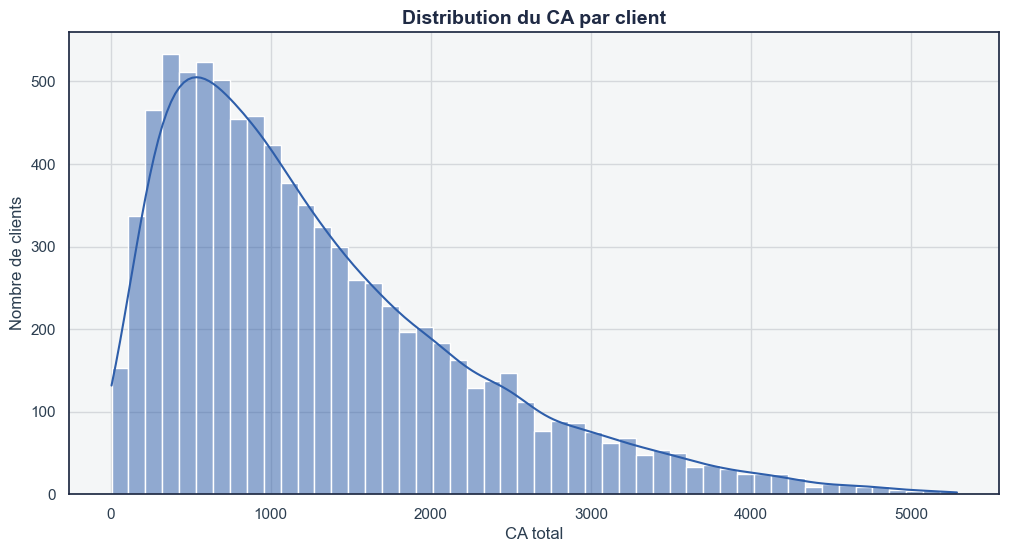

======================Statistiques descriptives du CA par client :==============
count    8596.000000
mean     1296.343300
std       958.404544
min         6.310000
25%       562.645000
50%      1045.585000
75%      1796.015000
max      5285.820000
Name: ca_total, dtype: float64


In [8]:
# Visualisation de la distribution du CA par client pour le segment BtoC
sns.histplot(
    ca_client['ca_total'], bins=50, kde=True
)
plt.title("Distribution du CA par client")
plt.xlabel("CA total")
plt.ylabel("Nombre de clients")
plt.show()

print("=" * 80)
print("======================Statistiques descriptives du CA par client :==============")
print("=" * 80)
print(ca_client['ca_total'].describe())
print("=" * 80)

La courbe de distribution du CA total des clients BtoC est très asymétrique, avec une majorité de clients réalisant des achats de faible montant et une minorité de clients réalisant des achats de montant élevé. 
La moyenne est supérieure à la médiane, ce qui confirme la présence de valeurs extrêmes (clients très dépensiers) qui tirent la moyenne vers le haut.
Le max est nettement au-dessus de Q3, ce qui indique la présence de valeurs aberrantes.
L'écart-type est très élevé, ce qui confirme la grande dispersion des montants d'achat parmi les clients BtoC.

<div style="background-color: #2E5EAA; border: 1px solid #2E5EAA;" >
<h3 style="margin: auto; padding: 20px; color: #F4F6F7; "> Inspection de base des tests à réaliser sur les variables quantitatives et catégorielles</h3>
</div>

In [9]:
# Inspection de base des fichiers grâce à la fonction afficher_resume_tests_statistiques()
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "./.")))

from P9_Tests_Statistiques import afficher_resume_tests_statistiques

afficher_resume_tests_statistiques(transactions_BtoC, "Transactions enrichies BtoC")


🧪 RAPPORT DE TESTS STATISTIQUES : TRANSACTIONS ENRICHIES BTOC

Variables quantitatives :
price, categ, birth, ca_total, age, annee

Variables qualitatives :
id_prod, date, session_id, client_id, sex, statut_actif, segment_client, mois, categ_label

Tests conseilles :


,Type de variables,Variables candidates,Tests conseilles
0,Quantitatives,"price, categ, birth, ca_total, age, annee","Shapiro, KS, Spearman, Pearson"
1,Quantitatives vs qualitatives,"price, categ, birth, ca_total, age, annee vs i...","Mann-Whitney, t-test, ANOVA, Kruskal-Wallis se..."
2,Qualitatives,"id_prod, date, session_id, client_id, sex, sta...","Chi2, Fisher si effectifs faibles"


## 1 - 👩‍🦰👨‍🦱 Lien entre genre et catégories des livres achetés  (sex × categ_label → Chi2)

Pour étudier le lien entre deux variables qualitatives, comme le genre et la catégorie de livres achetés, le test du 
χ
2
χ 
2
  d’indépendance est adapté.
La visualisation pertinente en amont est un tableau de contingence (et éventuellement un graphique en barres empilées), plutôt qu’un nuage de points.

Pourquoi ce test ?
Le test du 
χ
2 <span style="color:#C2188B; font-weight:bold;">
χ 
2
  permet de vérifier s’il existe une association statistiquement significative entre deux variables qualitatives.</span>

Objectif de l’étude
Déterminer si la répartition des catégories de livres achetés  <span style="color:#C2188B; font-weight:bold;">varie selon le genre (F/H),</span> afin d’éclairer des décisions marketing (offres ciblées, saisonnalité, etc.).

Conditions à vérifier :

- Observations indépendantes.
- Données exprimées en effectifs (pas en pourcentages).
- Effectifs théoriques suffisants dans le tableau de contingence.

Règle pratique :

- au moins 80% des cases avec effectif théorique ≥5 ;
- aucune case avec effectif théorique <1.


Si ces conditions ne sont pas respectées, on privilégie un regroupement de modalités ou un test exact (Fisher), surtout en tableau 
2
×
2
.

Un tableau de contingence montre les effectifs observés par combinaison sexe × catégorie. Il faut vérifier sur un histogramme empilé que les effectifs théoriques sont suffisants pour valider le test du χ2. Si ce n’est pas le cas, il est nécessaire d’utiliser un test exact de Fisher pour évaluer l'association entre le genre et les catégories de livres achetés.


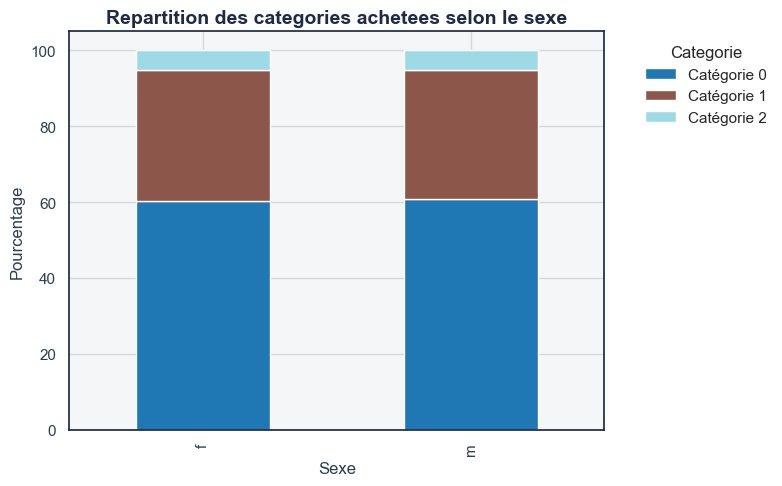

categ_label,Catégorie 0,Catégorie 1,Catégorie 2
sex,,,
f,200793,115721,16980
m,186488,104884,15868


In [36]:
# Etape 1. Barres empilees a 100 % avant le test du Chi2
# Preparation robuste du DataFrame source
if 'df_BtoC' not in locals():
    df_BtoC = transactions_BtoC.copy()

# Choix de la colonne categorie disponible
col_categ = 'categ_label' if 'categ_label' in df_BtoC.columns else 'categ'

# Tableau de contingence observe (Sexe x Categorie)
table = pd.crosstab(df_BtoC['sex'], df_BtoC[col_categ])

# Conversion en pourcentage par ligne (100 % par sexe)
table_pct = table.div(table.sum(axis=1), axis=0) * 100

# Visualisation
table_pct.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='tab20')
plt.title('Repartition des categories achetees selon le sexe')
plt.xlabel('Sexe')
plt.ylabel('Pourcentage')
plt.legend(title='Categorie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

display(table)

L'histogramme emplié à 100%  permet de visualiser la répartition des catégories de livres achetés par genre. Si les barres sont très différentes entre les genres, cela peut indiquer une association entre le genre et les catégories de livres achetés. Cependant, pour confirmer cette association, il est nécessaire de réaliser un test statistique approprié, comme le test du χ2 ou le test exact de Fisher, en fonction des effectifs théoriques. Sur ce graphique, on peut observer que les barres sont strictement identiques entre les genres, ce qui suggère une absence d'association entre le genre et les catégories de livres achetés en valeur absolue (Hypothèse nulle H0 : le genre et les catégories de livres achetés sont indépendants).

In [13]:
# Etape 2 - Test du chi2
from scipy.stats import chi2_contingency
chi2, p_value, ddl, expected = chi2_contingency(table, correction =False)
print(f"Chi2: {chi2}, p-value: {p_value:.3e}, ddl: {ddl}")

# appel de la fonction interne de test du chi 2 pour vérification 
from P9_Tests_Statistiques import test_chi2, afficher_resume_chi2
res = test_chi2(df_BtoC, "sex", "categ", alpha=0.05)
afficher_resume_chi2(res, afficher_tables=True)


Chi2: 22.66856665178056, p-value: 1.196e-05, ddl: 2
🧪 Résumé test Chi2 : sex x categ
Chi2              : 22.6686
p-value           : 0.000012
alpha             : 0.050
degrés de liberté : 2
dépendance significative : Oui
% cases attendues < 5    : 0.0%
conditions Chi2 respectées : Oui
Conclusion : rejet de l'indépendance (association probable entre les variables).

Table de contingence (observée) :


categ,0,1,2
sex,,,
f,200793,115721,16980
m,186488,104884,15868



Effectifs théoriques :


categ,0,1,2
sex,,,
f,201574.896625,114822.131914,17096.971461
m,185706.103375,105782.868086,15751.028539


**Conclusion statistique :** <span style="color:#C2188B; font-weight:bold;">Le test χ² donne une p-value très faible (< 0,05).</span> On rejette l'hypothèse d'indépendance : il existe une association significative entre le sexe et la catégorie de livres achetés.

---
**💼 Interprétation métier pour Julie**

<span style="color:#C2188B; font-weight:bold;">Le genre du client influence réellement les catégories de livres achetées. Ce n'est pas le fruit du hasard.</span>

**Actions BI recommandées :**
- Segmenter les campagnes marketing par genre : ne pas envoyer les mêmes recommandations aux femmes et aux hommes.
- Adapter les mises en avant sur le site selon le profil de l'utilisateur connecté.
- Analyser les saisonnalités par genre pour cibler les promotions au bon moment.

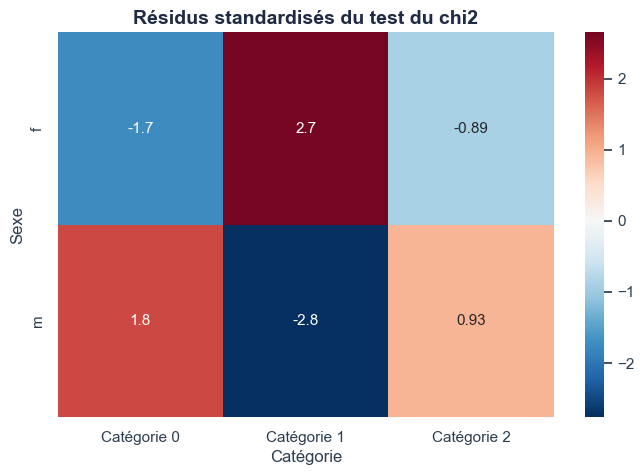

Chi2 = 22.669, p-value = 0.0000


In [15]:
# Etape 3- Visualisation Heatmap des résidus standardisés
expected_df = pd.DataFrame(expected, index=table.index, columns=table.columns)
residus = (table - expected_df) / expected_df.pow(0.5)

plt.figure(figsize=(8, 5))
sns.heatmap(residus, annot=True, cmap="RdBu_r", center=0)
plt.title("Résidus standardisés du test du chi2")
plt.xlabel("Catégorie")
plt.ylabel("Sexe")
plt.show()

print(f"Chi2 = {chi2:.3f}, p-value = {p_value:.4f}")

**Conclusion visuelle :** La heatmap des résidus standardisés montre les contributions de chaque case au χ². Les cellules en rouge foncé (résidus élevés) indiquent des associations fortes, les cellules en bleu foncé des sous-représentations.

Les femmes achètent significativement plus de livres de la **catégorie 1**, tandis que les hommes surreprésentent les **catégories 0 et 2**.

---
**💼 Interprétation métier pour Julie**

Ces écarts ne sont pas anecdotiques : ils reflètent des **préférences de lecture structurées par le genre**.

**Actions BI recommandées :**
- Créer des **newsletters distinctes** : contenu orienté <span style="color:#C2188B; font-weight:bold;">catégorie 1 pour les clientes, catégories 0 et 2 pour les clients.</span>
- Tester des **offres croisées** (<span style="color:#C2188B; font-weight:bold;">cross-sell</span>) ciblées : proposer aux femmes achetant catégorie 1 une sélection de catégorie 0, et vice-versa.
- Valoriser ces insights dans les dashboards de pilotage pour orienter les décisions d'achat (choix des titres à stocker).

## 2 - 💶  Lien entre âge des clients et montant total des achats (age × ca_total → Pearson/Spearman)

Dans cette partie, on cherche à savoir si l'âge est associé au **niveau de dépense total** des clients BtoC.

**Démarche :**
- agréger le CA total par client,
- explorer visuellement les distributions (histogrammes) et la relation (nuage de points),
- tester la normalité (Shapiro),
- comparer Pearson et Spearman pour conclure de façon robuste.

**Lecture attendue :**
- si la relation est significative, l'âge peut orienter la stratégie de ciblage marketing par niveau de valeur client ;
- si la relation est faible ou non significative, il faudra privilégier d'autres variables explicatives (fréquence, catégories, ancienneté).

In [16]:
#Etape 1 : Agréger par client, age et montant total (segment BtoC)
client_age = transactions_BtoC.groupby(['client_id', 'age'])['price'].sum().reset_index()
client_age.rename(columns={'price': 'ca_total'}, inplace=True)
client_age

,client_id,age,ca_total
0,c_1,66,365.50
1,c_1,67,219.23
2,c_1,68,44.29
3,c_10,65,586.18
4,c_10,66,602.93
...,...,...,...
24173,c_998,21,1179.06
24174,c_998,22,498.96
24175,c_999,57,226.60
24176,c_999,58,394.11


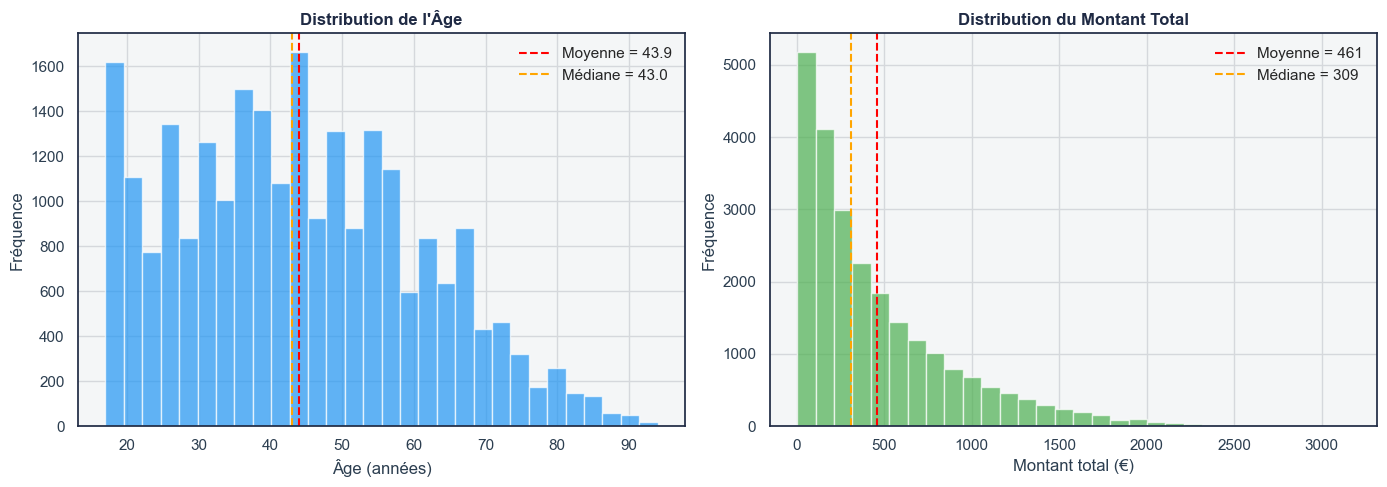

In [17]:
#Etape 2 :  Histogrammes des deux variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution de l'âge
axes[0].hist(client_age['age'], bins=30, edgecolor='white', color='#2196F3', alpha=0.7)
axes[0].axvline(client_age['age'].mean(), color='red', linestyle='--', label=f"Moyenne = {client_age['age'].mean():.1f}")
axes[0].axvline(client_age['age'].median(), color='orange', linestyle='--', label=f"Médiane = {client_age['age'].median():.1f}")
axes[0].set_title('Distribution de l\'Âge', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Âge (années)')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Distribution du montant total
axes[1].hist(client_age['ca_total'], bins=30, edgecolor='white', color='#4CAF50', alpha=0.7)
axes[1].axvline(client_age['ca_total'].mean(), color='red', linestyle='--', label=f"Moyenne = {client_age['ca_total'].mean():.0f}")
axes[1].axvline(client_age['ca_total'].median(), color='orange', linestyle='--', label=f"Médiane = {client_age['ca_total'].median():.0f}")
axes[1].set_title('Distribution du Montant Total', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Montant total (€)')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()
plt.show()

Les deux histogrammes montrent des profils de distribution très différents :

1. Âge
Distribution relativement étalée, avec une moyenne et une médiane très proches (43,9 vs 43,0).
Cela suggère une <span style="color:#C2188B; font-weight:bold;">asymétrie faible à modérée sur l’âge.</span>

2. Montant total des achats
Distribution fortement asymétrique à droite, avec une longue queue de gros montants.
La moyenne est nettement supérieure à la médiane (461 vs 309), ce qui traduit la <span style="color:#C2188B; font-weight:bold;">présence de clients à très forte dépense qui tirent la moyenne vers le haut.</span>

Le montant total n’a pas une distribution normale (et possiblement pas l’âge non plus selon Shapiro).
Il faut donc interpréter Pearson avec prudence et <span style="color:#C2188B; font-weight:bold;">privilégier Spearman si la normalité n’est pas respectée.</span>

Test de Shapiro pour l'age : W=0.973, p-value=9.504e-54
Test de Shapiro pour le CA total : W=0.840, p-value=7.392e-92


c:\Users\feria\Documents\P9\lapage_project\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 24178.
  res = hypotest_fun_out(*samples, **kwds)


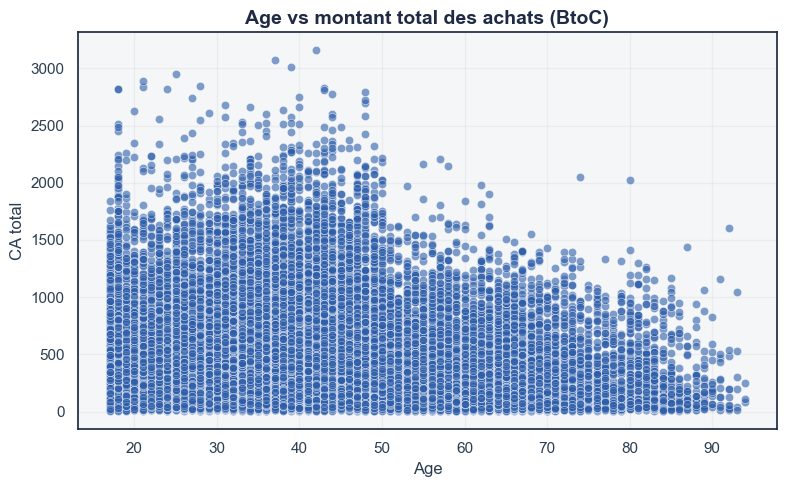

In [28]:
# Etape 3 : Visualiser la relation entre le CA total par client et l'age du client
import scipy.stats as stats

shapiro_age = stats.shapiro(client_age['age'])
shapiro_ca = stats.shapiro(client_age['ca_total'])

print(f"Test de Shapiro pour l'age : W={shapiro_age.statistic:.3f}, p-value={shapiro_age.pvalue:.3e}")
print(f"Test de Shapiro pour le CA total : W={shapiro_ca.statistic:.3f}, p-value={shapiro_ca.pvalue:.3e}")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=client_age, x='age', y='ca_total', alpha=0.6)
plt.title("Age vs montant total des achats (BtoC)")
plt.xlabel("Age")
plt.ylabel("CA total")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 Conclusion du nuage de points
<span style="color:#C2188B; font-weight:bold;">Le nuage de points ne montre pas de relation linéaire forte entre l'âge et le montant total des achats par client.
On observe surtout une forte dispersion des montants pour tous les âges, avec quelques valeurs extrêmes.
Cette lecture visuelle doit être confirmée par les tests statistiques (Pearson et Spearman).</span>

In [20]:
#Etape 4 : Confirmation de Tests de normalite (Shapiro-Wilk) sur age et montant total

from P9_Tests_Statistiques import test_shapiro
res_age = test_shapiro(client_age["age"], alpha=0.05)
res_ca = test_shapiro(client_age["ca_total"], alpha=0.05)

print("AGE -> stat:", f"{res_age['statistique']:.4f}", "| p-value:", f"{res_age['p_value']:.3e}")
print("CA  -> stat:", f"{res_ca['statistique']:.4f}", "| p-value:", f"{res_ca['p_value']:.3e}")


AGE -> stat: 0.9734 | p-value: 9.504e-54
CA  -> stat: 0.8402 | p-value: 7.392e-92


c:\Users\feria\Documents\P9\lapage_project\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 24178.
  res = hypotest_fun_out(*samples, **kwds)


Conclusion des tests de normalité (Shapiro-Wilk)

| Variable | Statistique W | p-value | Normale ? |
|---|---|---|---|
| Âge | 0.973 | 9.504e-54 | ❌ Non |
| CA total | 0.840 | 7.392e-92 | ❌ Non |

**Lecture des résultats :**

- **Âge (W = 0.973)** : Le W est proche de 1, ce qui indique une forme assez proche de la normale. Cependant, la p-value est extrêmement petite (≈ 10⁻⁵⁴) — avec un grand échantillon, le test est très puissant et détecte même des écarts infimes à la normalité. En pratique, la distribution de l'âge est *quasi-normale*, mais techniquement rejetée.

- **CA total (W = 0.840)** : Le W s'éloigne nettement de 1, confirmant la forte asymétrie à droite déjà visible sur l'histogramme. La distribution est clairement non-normale : une minorité de clients concentre des CA très élevés.

**Décision méthodologique :**

> Les deux variables rejettent la normalité (p-values < 0,05). Le test de **Spearman** est donc le test de référence pour quantifier la relation entre âge et CA total. Le test de Pearson sera présenté à titre indicatif, mais son interprétation devra rester prudente.

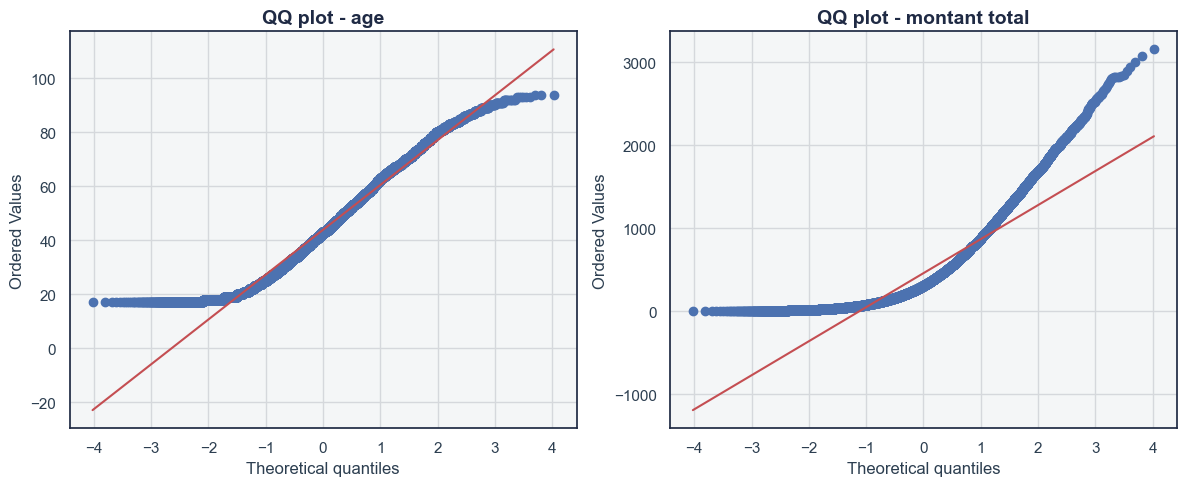

Shapiro AGE -> W=0.9734 p=9.504e-54
Shapiro CA  -> W=0.8402 p=7.392e-92


c:\Users\feria\Documents\P9\lapage_project\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 24178.
  res = hypotest_fun_out(*samples, **kwds)


In [29]:
# Etape 5 : Visualisation QQ plots pour verifier visuellement la normalite de age et ca_total
import scipy.stats as stats
import matplotlib.pyplot as plt
from P9_Tests_Statistiques import test_shapiro

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
stats.probplot(client_age["age"], dist="norm", plot=axes[0])
axes[0].set_title("QQ plot - age")

stats.probplot(client_age["ca_total"], dist="norm", plot=axes[1])
axes[1].set_title("QQ plot - montant total")

plt.tight_layout()
plt.show()

# Verification numerique de la normalite (Shapiro-Wilk)
res_age = test_shapiro(client_age["age"], alpha=0.05)
res_ca = test_shapiro(client_age["ca_total"], alpha=0.05)
print("Shapiro AGE ->", f"W={res_age['statistique']:.4f}", f"p={res_age['p_value']:.3e}")
print("Shapiro CA  ->", f"W={res_ca['statistique']:.4f}", f"p={res_ca['p_value']:.3e}")

Les QQ plots confirment visuellement le diagnostic de normalité: 
<span style="color:#C2188B; font-weight:bold;">plus les points s'écartent de la droite, moins l'hypothèse de normalité est crédible.</span>

In [22]:
#Etape6 :  Mesurer la correlation monotone (Spearman)
from scipy.stats import spearmanr
rho_spearman, p_spearman = spearmanr(client_age["age"], client_age["ca_total"])
print(f"Spearman rho = {rho_spearman:.4f} | p-value = {p_spearman:.3e}")

from P9_Tests_Statistiques import test_spearman, afficher_resume_spearman
res_sp = test_spearman(client_age, "age", "ca_total", alpha=0.05)
afficher_resume_spearman(res_sp)


Spearman rho = -0.1838 | p-value = 9.801e-183
🧪 Résumé Spearman : age x ca_total
Coefficient rho : -0.1838
p-value         : 9.801e-183
alpha           : 0.050
Significatif    : Oui
Force           : faible
Direction       : négative
Conclusion : corrélation monotone négative de force faible entre age et ca_total.


**Conclusion statistique Spearman :** Le test de Spearman mesure une relation monotone, plus robuste en présence de non-normalité et de valeurs extrêmes. La conclusion principale repose sur la p-value et le coefficient rho. Si Pearson et Spearman convergent, l'interprétation est renforcée ; sinon, Spearman est à privilégier quand les conditions de normalité ne sont pas respectées.

---
**💼 Interprétation métier pour Julie — âge vs montant total des achats**

Si la corrélation est **non significative** (p-value > 0,05) : l'âge n'explique pas le niveau de dépense. Tous les groupes d'âge dépensent de façon similaire en moyenne. La segmentation marketing par âge sur ce critère serait peu pertinente.

Si la corrélation est **significative** : <span style="color:#C2188B; font-weight:bold;"> il existe une tendance — les clients plus âgés (ou plus jeunes) dépensent davantage.</span>

**Actions BI recommandées selon le résultat :**
- Si pas de corrélation → chercher d'autres variables explicatives du CA (fréquence, catégorie, ancienneté client).
- Si corrélation positive avec l'âge → cibler les seniors avec des offres premium ou des abonnements fidélité.
- Si corrélation négative → <span style="color:#C2188B; font-weight:bold;">les jeunes clients sont des acheteurs actifs : investir sur leur fidélisation dès l'entrée dans la base.</span>

<a id="RNCP37837BC05-FREQUENCY"></a>

## 3 - 📊 Lien entre âge des clients et la fréquence d'achat (age × frequence_achat → Pearson/Spearman)

<div style="font-size: 12px; color: #666; margin-top: 10px;">
<strong>Compétences :</strong> <span style="background-color: #E8F4F8; padding: 2px 6px; border-radius: 3px;">Analyses multivariées</span> - <span style="background-color: #E8F4F8; padding: 2px 6px; border-radius: 3px;">Feature Engineering</span>
</div>

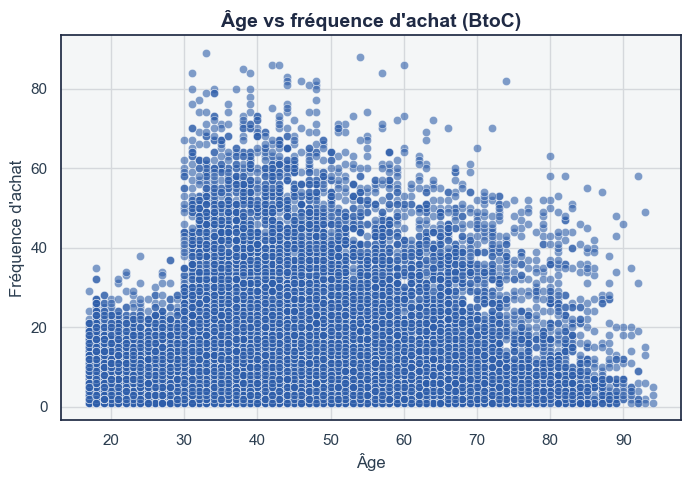

,client_id,age,frequence_achat
0,c_1,66,15
1,c_1,67,18
2,c_1,68,1
3,c_10,65,16
4,c_10,66,15


In [23]:
# Etape 1 : - Préparation des données : âge vs fréquence d'achat
col_achat = None
for candidat in ["session_id", "transaction_id", "id_prod"]:
    if candidat in transactions_BtoC.columns:
        col_achat = candidat
        break

if col_achat is None:
    # Fallback : fréquence basée sur le nombre de lignes transactionnelles
    df_freq = (
        transactions_BtoC.groupby(["client_id", "age"]) 
        .size()
        .reset_index(name="frequence_achat")
    )
else:
    # Fréquence = nombre d'achats uniques par client
    df_freq = (
        transactions_BtoC.groupby(["client_id", "age"])[col_achat]
        .nunique()
        .reset_index(name="frequence_achat")
    )

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_freq, x="age", y="frequence_achat", alpha=0.6)
plt.title("Âge vs fréquence d'achat (BtoC)")
plt.xlabel("Âge")
plt.ylabel("Fréquence d'achat")
plt.show()

df_freq.head()

Conclusion visuelle Etape 1 : Nuage de points
- Le nuage de points permet de repérer une tendance éventuelle entre l'âge et la fréquence d'achat, mais la dispersion reste importante.
- <span style="color:#C2188B; font-weight:bold;">La validation statistique est nécessaire pour conclure sur l'existence et la force de la relation.</span>

In [24]:
# Etape2 :  Tests statistiques de normalité + Pearson + Spearman
from P9_Tests_Statistiques import test_shapiro, test_pearson, test_spearman, afficher_resume_pearson, afficher_resume_spearman

res_age_freq = test_shapiro(df_freq["age"], alpha=0.05)
res_freq = test_shapiro(df_freq["frequence_achat"], alpha=0.05)

print("Shapiro AGE       ->", f"W={res_age_freq['statistique']:.4f}", f"p={res_age_freq['p_value']:.3e}")
print("Shapiro FREQUENCE ->", f"W={res_freq['statistique']:.4f}", f"p={res_freq['p_value']:.3e}")

res_p_freq = test_pearson(df_freq, "age", "frequence_achat", alpha=0.05)
afficher_resume_pearson(res_p_freq)

res_sp_freq = test_spearman(df_freq, "age", "frequence_achat", alpha=0.05)
afficher_resume_spearman(res_sp_freq)

Shapiro AGE       -> W=0.9734 p=9.504e-54
Shapiro FREQUENCE -> W=0.7951 p=5.895e-98
🧪 Résumé Pearson : age x frequence_achat
Coefficient r : +0.1015
p-value       : 2.245e-56
alpha         : 0.050
Significatif  : Oui
Force         : faible
Direction     : positive
Conclusion : corrélation linéaire positive de force faible entre age et frequence_achat.
⚠️  Valide uniquement si les deux variables sont normalement distribuées.
🧪 Résumé Spearman : age x frequence_achat
Coefficient rho : +0.1092
p-value         : 5.231e-65
alpha           : 0.050
Significatif    : Oui
Force           : faible
Direction       : positive
Conclusion : corrélation monotone positive de force faible entre age et frequence_achat.


c:\Users\feria\Documents\P9\lapage_project\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 24178.
  res = hypotest_fun_out(*samples, **kwds)


**Conclusion statistique Etape2:** La conclusion se base sur les p-values des tests de corrélation. En pratique, si les conditions de normalité ne sont pas respectées, <span style="color:#C2188B; font-weight:bold;">l'interprétation de Spearman est prioritaire pour qualifier la relation entre âge et fréquence d'achat.</span>

---
**💼 Interprétation métier pour Julie — âge vs fréquence d'achat**

Si la corrélation est **non significative** : l'âge n'est pas un bon prédicteur de la fréquence de visite ou d'achat. Tous les groupes d'âge ont des comportements similaires en matière de régularité.

Si la corrélation est **significative** : <span style="color:#C2188B; font-weight:bold;">certaines tranches d'âge achètent plus souvent que d'autres.</span>

**Actions BI recommandées selon le résultat :**
- <span style="color:#C2188B; font-weight:bold;">Si les jeunes achètent plus fréquemment → mettre en place des **programmes de fidélité** adaptés (points, avantages cumulatifs) pour capitaliser sur leur engagement.</span>
- <span style="color:#C2188B; font-weight:bold;">Si les seniors achètent moins fréquemment → les relancer avec des **communications de réactivation** (emailings "coup de cœur", nouveautés saisonnières).</span>
- <span style="color:#C2188B; font-weight:bold;">Si pas de corrélation → la fréquence est peut-être davantage liée aux habitudes personnelles ou aux événements (rentrée, Noël) : analyser la saisonnalité des achats par segment.</span>

<a id="RNCP37837BC05-BASKET"></a>

## 4 - 🛒 Lien entre âge des clients et taille du panier moyen (age × panier_moyen → Pearson/Spearman)

<div style="font-size: 12px; color: #666; margin-top: 10px;">
<strong>Compétences :</strong> <span style="background-color: #E8F4F8; padding: 2px 6px; border-radius: 3px;">Analyses multivariées</span> - <span style="background-color: #E8F4F8; padding: 2px 6px; border-radius: 3px;">Feature Engineering</span>
</div>

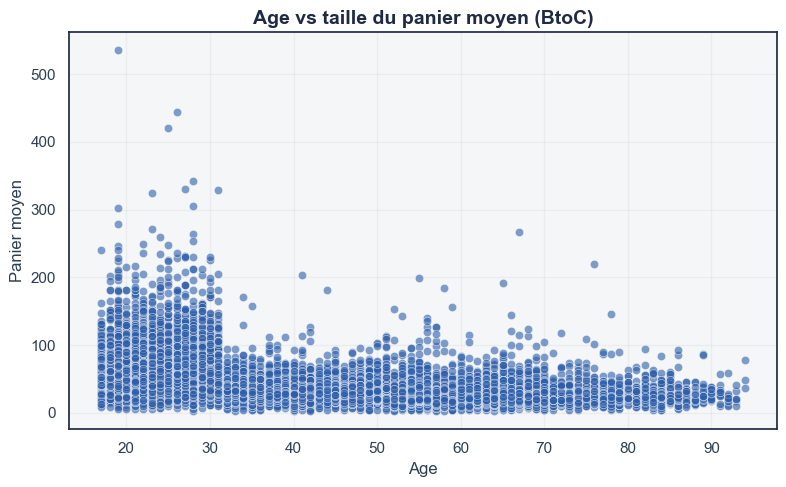

,client_id,age,ca_total,nb_achats,panier_moyen
0,c_1,66,365.50,15,24.366667
1,c_1,67,219.23,18,12.179444
2,c_1,68,44.29,1,44.290000
3,c_10,65,586.18,16,36.636250
4,c_10,66,602.93,15,40.195333


In [30]:
# Section 4 - Preparation des donnees : age vs panier moyen
import numpy as np

if 'df_BtoC' not in locals():
    df_BtoC = transactions_BtoC.copy()

col_achat = None
for candidat in ["session_id", "transaction_id", "id_prod"]:
    if candidat in df_BtoC.columns:
        col_achat = candidat
        break

if col_achat is None:
    df_panier = (
        df_BtoC.groupby(["client_id", "age"], as_index=False)
        .agg(ca_total=("price", "sum"), nb_achats=("price", "size"))
    )
else:
    df_panier = (
        df_BtoC.groupby(["client_id", "age"], as_index=False)
        .agg(ca_total=("price", "sum"), nb_achats=(col_achat, "nunique"))
    )

df_panier["panier_moyen"] = df_panier["ca_total"] / df_panier["nb_achats"].replace(0, np.nan)
df_panier = df_panier.dropna(subset=["panier_moyen"])

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_panier, x="age", y="panier_moyen", alpha=0.6)
plt.title("Age vs taille du panier moyen (BtoC)")
plt.xlabel("Age")
plt.ylabel("Panier moyen")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

df_panier.head()

### Conclusion visuelle Section 4
Le graphique visualise la variation du panier moyen selon l'âge.
Une éventuelle tendance doit être validée par les tests de corrélation, car la dispersion peut masquer ou simuler un effet.

In [31]:
# Tests statistiques Section 4 : normalite + Pearson + Spearman
from P9_Tests_Statistiques import test_shapiro, test_pearson, test_spearman, afficher_resume_pearson, afficher_resume_spearman

# Securite: reconstruire df_panier si la cellule precedente n'a pas ete executee
if 'df_panier' not in locals():
    if 'df_BtoC' not in locals():
        df_BtoC = transactions_BtoC.copy()
    col_achat = None
    for candidat in ["session_id", "transaction_id", "id_prod"]:
        if candidat in df_BtoC.columns:
            col_achat = candidat
            break
    if col_achat is None:
        df_panier = (
            df_BtoC.groupby(["client_id", "age"], as_index=False)
            .agg(ca_total=("price", "sum"), nb_achats=("price", "size"))
        )
    else:
        df_panier = (
            df_BtoC.groupby(["client_id", "age"], as_index=False)
            .agg(ca_total=("price", "sum"), nb_achats=(col_achat, "nunique"))
        )
    df_panier["panier_moyen"] = df_panier["ca_total"] / df_panier["nb_achats"].replace(0, np.nan)
    df_panier = df_panier.dropna(subset=["panier_moyen"])

res_age_panier = test_shapiro(df_panier["age"], alpha=0.05)
res_panier = test_shapiro(df_panier["panier_moyen"], alpha=0.05)

print("Shapiro AGE    ->", f"W={res_age_panier['statistique']:.4f}", f"p={res_age_panier['p_value']:.3e}")
print("Shapiro PANIER ->", f"W={res_panier['statistique']:.4f}", f"p={res_panier['p_value']:.3e}")

res_p_panier = test_pearson(df_panier, "age", "panier_moyen", alpha=0.05)
afficher_resume_pearson(res_p_panier)

res_sp_panier = test_spearman(df_panier, "age", "panier_moyen", alpha=0.05)
afficher_resume_spearman(res_sp_panier)

Shapiro AGE    -> W=0.9734 p=9.504e-54
Shapiro PANIER -> W=0.7624 p=1.083e-101
🧪 Résumé Pearson : age x panier_moyen
Coefficient r : -0.5232
p-value       : 0.000e+00
alpha         : 0.050
Significatif  : Oui
Force         : forte
Direction     : négative
Conclusion : corrélation linéaire négative de force forte entre age et panier_moyen.
⚠️  Valide uniquement si les deux variables sont normalement distribuées.
🧪 Résumé Spearman : age x panier_moyen
Coefficient rho : -0.6214
p-value         : 0.000e+00
alpha           : 0.050
Significatif    : Oui
Force           : forte
Direction       : négative
Conclusion : corrélation monotone négative de force forte entre age et panier_moyen.


c:\Users\feria\Documents\P9\lapage_project\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 24178.
  res = hypotest_fun_out(*samples, **kwds)


**Conclusion statistique Section 4 :** La significativité et la force du lien âge-panier moyen se lisent via la p-value et le coefficient de corrélation. Lorsque la normalité n'est pas vérifiée, la conclusion repose principalement sur Spearman.

---
**💼 Interprétation métier pour Julie — âge vs panier moyen**

Le panier moyen reflète la valeur unitaire de chaque visite d'achat : c'est un indicateur clé de la valeur perçue et du pouvoir d'achat consacré au livre.

Si la corrélation est **significative et positive** : les clients plus âgés dépensent plus par session d'achat.
→ Opportunité : leur proposer des **coffrets, éditions collector, ou offres premium** à valeur ajoutée.

Si la corrélation est **significative et négative** : les jeunes achètent en plus grande quantité par session mais à moindre coût unitaire (ex. livres de poche, promotions).
→ Opportunité : structurer des **offres multi-achats** (bundle, "3 pour 2") portées par les jeunes.

Si **non significative** : le panier moyen ne dépend pas de l'âge — d'autres variables sont à explorer (catégorie achetée, saisonnalité, ancienneté client).

**Actions BI recommandées :**
- Croiser le panier moyen avec la catégorie achetée pour affiner la stratégie tarifaire.
- Intégrer le panier moyen par tranche d'âge dans les dashboards de suivi de la valeur client (LTV).

<a id="RNCP37837BC05-CLUSTERING"></a>

## 5 - 📚 Lien entre âge des clients et catégorie des livres achetés (age × categ → Kruskal/ANOVA)

<div style="font-size: 12px; color: #666; margin-top: 10px;">
<strong>Compétences :</strong> <span style="background-color: #E8F4F8; padding: 2px 6px; border-radius: 3px;">Tests statistiques</span> - <span style="background-color: #E8F4F8; padding: 2px 6px; border-radius: 3px;">Feature Engineering (non supervisé)</span>
</div>

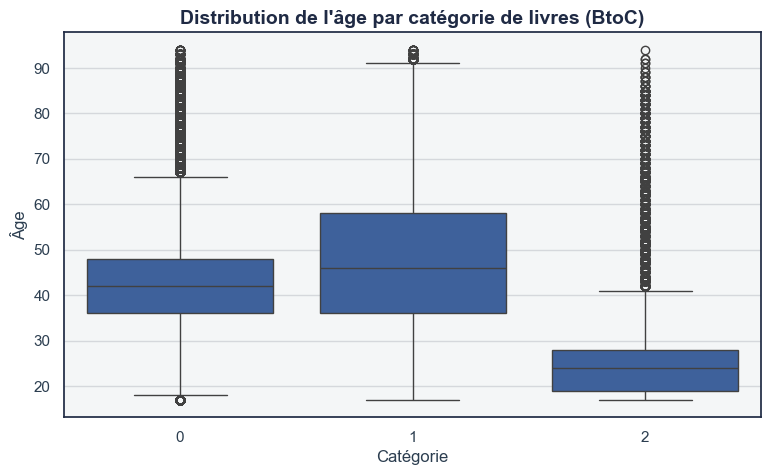

Kruskal-Wallis H = 71283.5758 | p-value = 0.000e+00
ANOVA (indicatif) F = 39585.5108 | p-value = 0.000e+00
Taille d'effet (epsilon^2) = 0.1113


In [35]:
# Section 5 - Âge (quantitative) vs catégorie (qualitative)
import numpy as np
from scipy.stats import kruskal, f_oneway

# Préparer les groupes d'âge par catégorie
df_age_categ = df_BtoC[["age", "categ"]].dropna().copy()
df_age_categ["categ"] = df_age_categ["categ"].astype(str)

groupes = [g["age"].values for _, g in df_age_categ.groupby("categ") if len(g) > 0]

# Visualisation
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_age_categ, x="categ", y="age")
plt.title("Distribution de l'âge par catégorie de livres (BtoC)")
plt.xlabel("Catégorie")
plt.ylabel("Âge")
plt.show()

# Tests globaux de comparaison entre catégories
h_stat, p_kruskal = kruskal(*groupes)
f_stat, p_anova = f_oneway(*groupes)

n = len(df_age_categ)
k = len(groupes)
epsilon2 = max(0.0, (h_stat - k + 1) / (n - k)) if n > k else np.nan

print(f"Kruskal-Wallis H = {h_stat:.4f} | p-value = {p_kruskal:.3e}")
print(f"ANOVA (indicatif) F = {f_stat:.4f} | p-value = {p_anova:.3e}")
print(f"Taille d'effet (epsilon^2) = {epsilon2:.4f}")

**Conclusion statistique Section 5 :** Le boxplot compare la distribution des âges selon les catégories de livres. Le test de Kruskal-Wallis permet de vérifier s'il existe une différence significative d'âge entre au moins deux catégories. Si la p-value est inférieure à 0,05, on conclut à une différence statistiquement significative des distributions d'âge selon la catégorie.

La taille d'effet ε² mesure la part de la variance d'âge expliquée par l'appartenance à une catégorie (0 = aucun effet, 1 = effet total). En dessous de 0,01 : effet négligeable ; entre 0,01 et 0,06 : faible ; au-delà de 0,06 : modéré à fort.

---
**💼 Interprétation métier pour Julie — âge vs catégorie de livres**

Si la différence est **significative** : certaines catégories sont davantage achetées par des tranches d'âge spécifiques. La librairie peut **personnaliser ses recommandations** selon l'âge du client.

Si la taille d'effet est **faible** (ε² < 0,01) : même si l'effet est statistiquement présent, il est trop petit pour actionner une segmentation coûteuse — d'autres critères sont plus discriminants.

**Actions BI recommandées selon le résultat :**
- Si un lien est confirmé → **enrichir le moteur de recommandation** en tenant compte de l'âge pour le tri des catégories affichées en page d'accueil.
- Construire des **profils types d'acheteurs** (persona) : ex. "25-35 ans → catégorie 0", "50+ ans → catégorie 1" — à valider avec les données réelles.
- Utiliser ce croisement pour calibrer les **stocks et achats éditoriaux** : anticiper la demande par catégorie selon le profil d'âge de la clientèle locale.

# 6 - Sauvegarde et export des figures et KPIS de Julie du dataset finalisé

## 6.1 Sauvegarde et export des Figures de Julie 

8 figures generees dans: ../../reports/figures
Cles exportees: ['julie_41_heatmap_residus', 'julie_41_stacked_bar', 'julie_42_hist', 'julie_42_qqplots', 'julie_42_scatter_age_ca', 'julie_43_scatter_freq', 'julie_44_scatter_panier', 'julie_45_boxplot_categ']


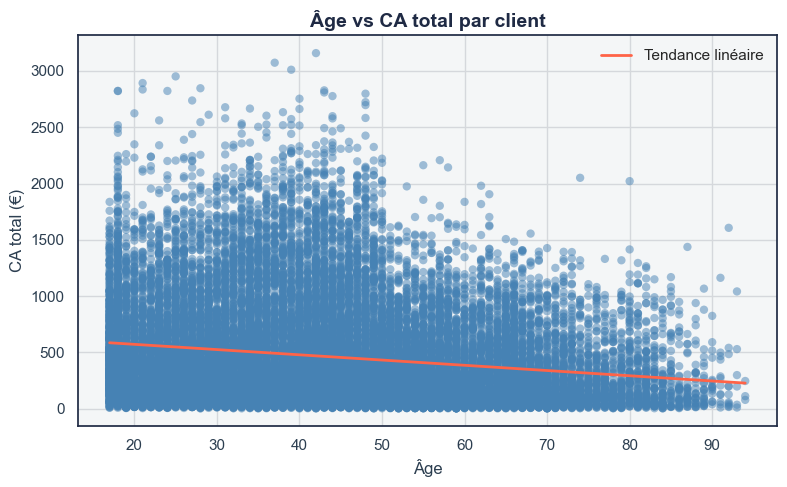

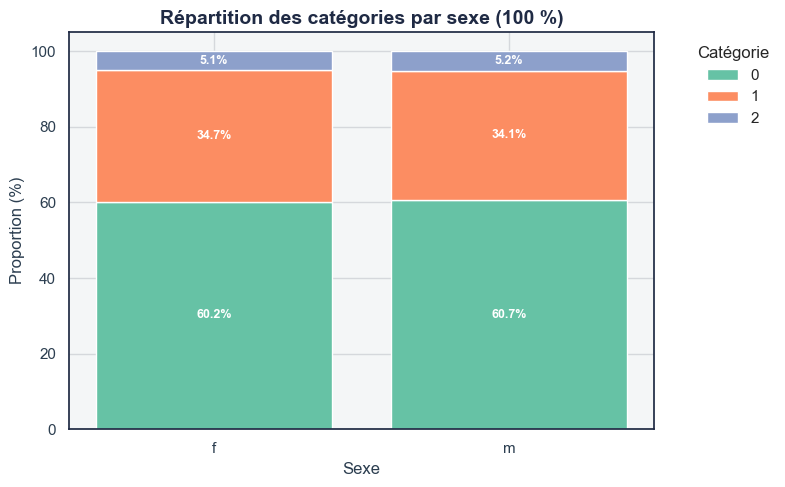

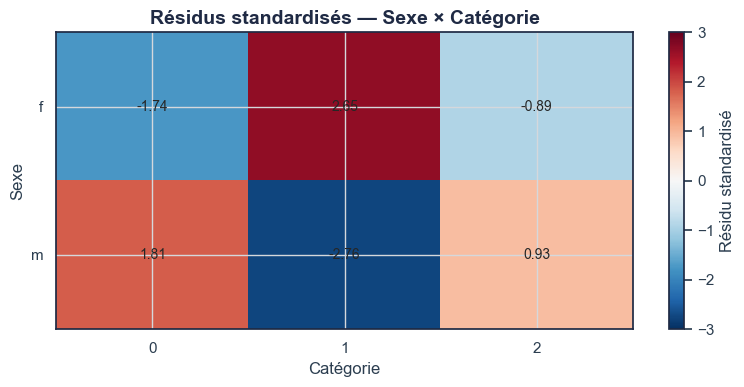

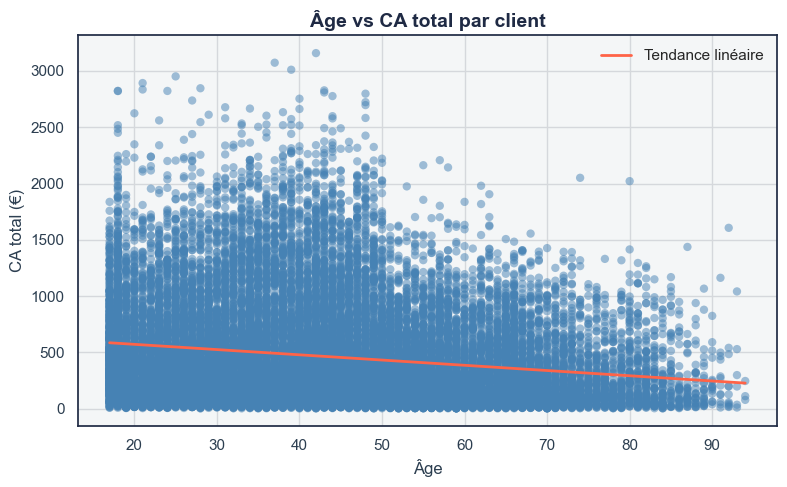

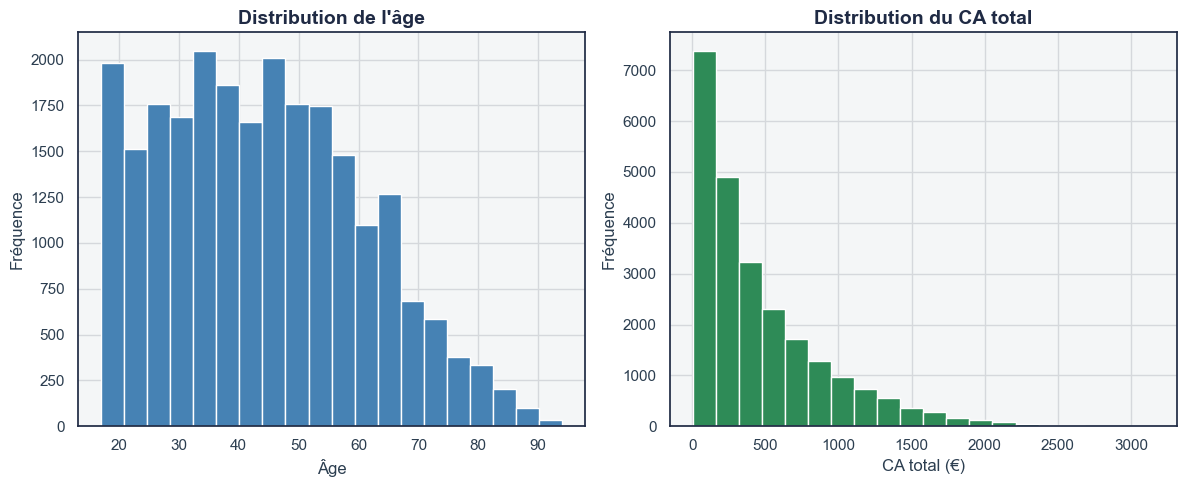

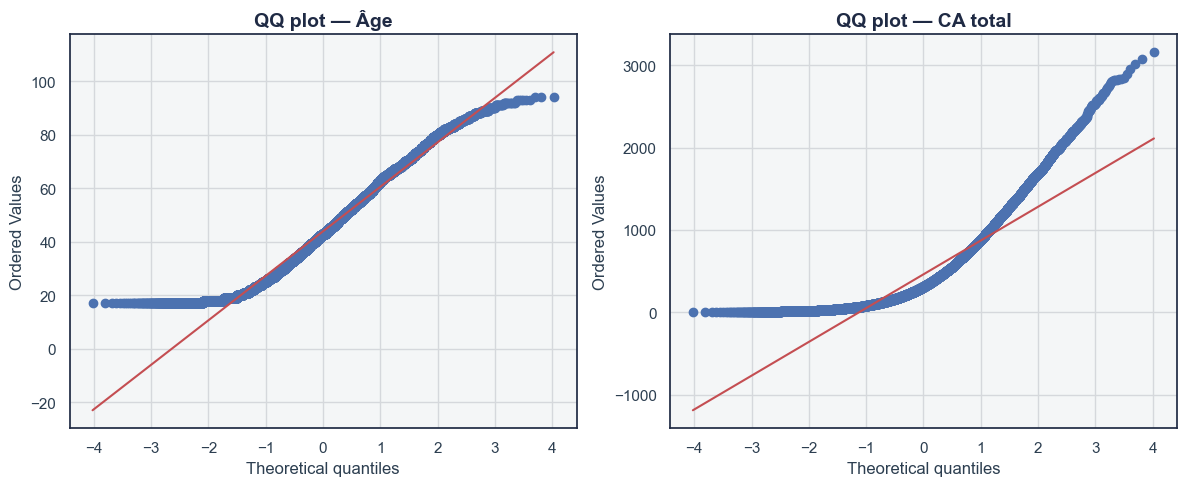

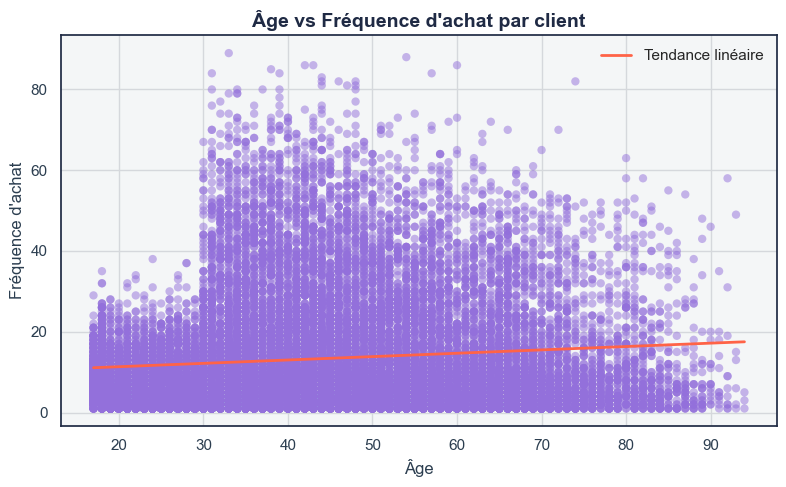

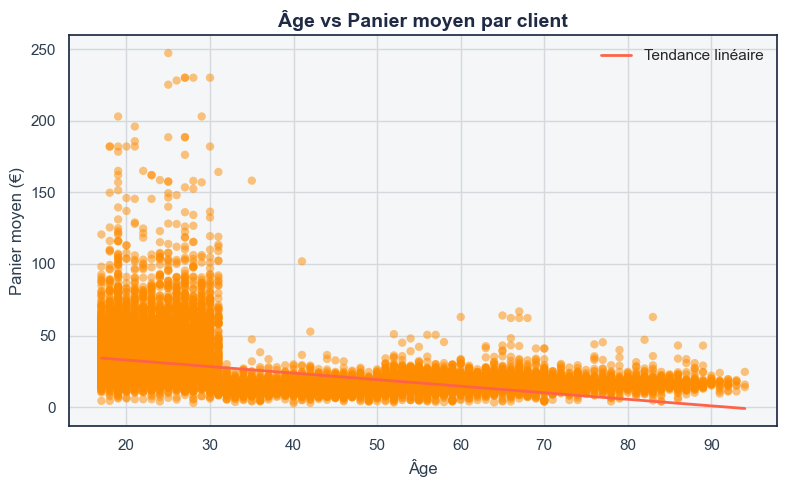

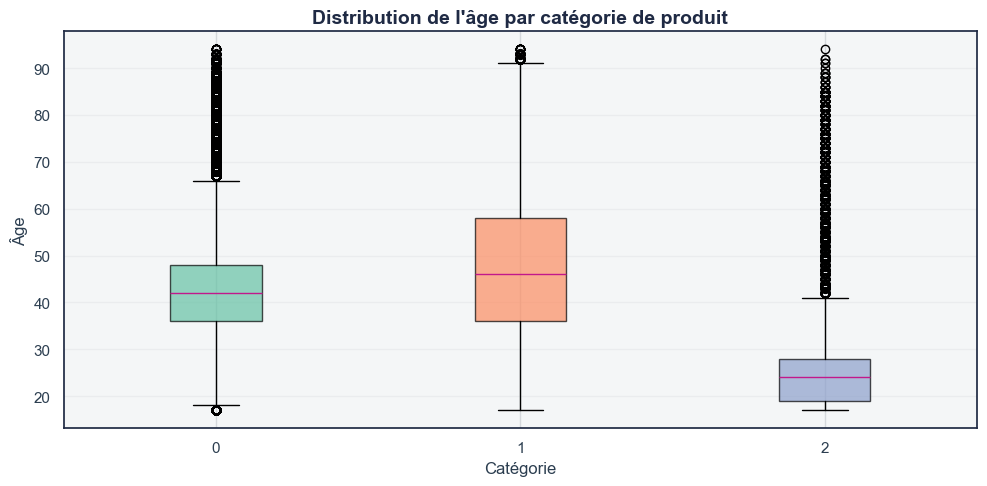

In [32]:
# 6.1 - Sauvegarde et export des figures Julie
import os
import sys

# Rend le module reutilisable accessible depuis notebooks/analyses
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../réutilisable (toutes phases)")))
from visualization import generate_julie_figures

# Source prioritaire: transactions_BtoC ; fallback sur df_BtoC si besoin
df_source = transactions_BtoC if "transactions_BtoC" in globals() else df_BtoC

# Export des figures dans le dossier rapport
output_dir = "../../reports/figures"
figs = generate_julie_figures(df_source, output_dir=output_dir)

print(f"{len(figs)} figures generees dans: {output_dir}")
print("Cles exportees:", sorted(figs.keys()))

# Affiche une figure cle
figs["julie_42_scatter_age_ca"]

## 6.2 Export du Rapport de Julie 

In [34]:
# 6.2 - Export du rapport KPI Julie
import os
import sys

# Rend src/ accessible depuis notebooks/analyses
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src")))
from kpi_export import ReportConfig, build_kpi_report_tables, export_kpi_report

config = ReportConfig(
    date_col="date",
    client_col="client_id",
    amount_col="price",
    segment_col="segment_client",
    freq="M",
    top_n=10
)

# Source de donnees: dataframe transactions charge en debut de notebook
df = transactions.copy()

tables = build_kpi_report_tables(df, config)
output_file = export_kpi_report(tables, "../../reports/4-kpi_report_enrichi_julie.xlsx")
print("Export cree:", output_file)

c:\Users\feria\Documents\P9\lapage_project\src\kpi_export.py:153: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample(cfg.freq)


Export cree: ..\..\reports\4-kpi_report_enrichi_julie.xlsx
